In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


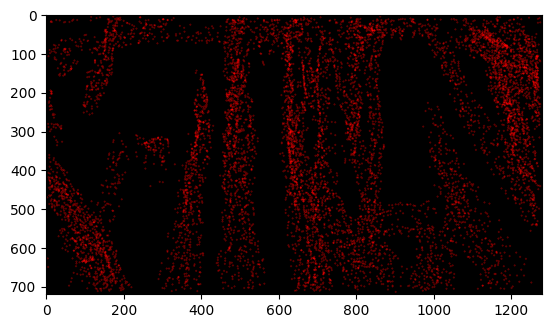

In [80]:

cap = cv.VideoCapture(r"data\human.mp4")
height, width = int(cap.get(4)), int(cap.get(3))
heatmap = np.zeros((height,width,3), np.uint8)

heatmap_color = [0,0,255]

while True:
    rec, frame1 = cap.read()
    rec, frame2 = cap.read()
    if not rec:
        break

    frame_diff = cv.absdiff(frame1, frame2)

    blur = cv.GaussianBlur(frame_diff, (3,3), 1)
    gray_frame_diff = cv.cvtColor(blur, cv.COLOR_BGR2GRAY)
    dilated = cv.dilate(gray_frame_diff, (55,55), 2)
    closed = cv.morphologyEx(dilated, cv.MORPH_CLOSE, (75,75))
    edges = cv.Canny(closed, 50,200)
    contours, _ =cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv.contourArea, reverse=True)

    for c in sorted_contours:
        if cv.contourArea(c) > 50:
            M = cv.moments(c)
            cx = int(M["m10"] / (M["m00"]+0.000001))
            cy = int(M["m01"] / (M["m00"]+0.000001))
            x,y,w,h = cv.boundingRect(c)

            cv.rectangle(frame2, (x,y), (x+w, y+h), (0,255,0), 3)
            cv.circle(heatmap, (cx,cy), 2, heatmap_color, 1)

            if heatmap[cy, cx].any():
                cv.circle(heatmap, (cx,cy), 2, heatmap_color, 1)

            
            
        



    cv.imshow("frame2",frame2)
    cv.imshow("heatmap", heatmap)
    if cv.waitKey(1) & 0xFF == 27:
        break


cap.release()
cv.destroyAllWindows()

plt.imshow(heatmap[...,::-1])



In [81]:
cv.imwrite(r"output\human.png", heatmap)

True